In [18]:
# Download the data
import os
from dotenv import load_dotenv
from roboflow import Roboflow

load_dotenv()
api_key = os.environ.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=api_key)
project = rf.workspace("cybertech-qde01").project("waste-classification-q75av-awlnx")
version = project.version(1)
dataset = version.download("multiclass")

loading Roboflow workspace...
loading Roboflow project...
loading Roboflow project...


In [ ]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = dataset.location

class_names = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

def load_roboflow_split(split_name, batch_size=32, image_size=(224, 224)):
    folder_path = os.path.join(base_path, split_name)
    csv_path = os.path.join(folder_path, "_classes.csv")
        
    df = pd.read_csv(csv_path)
    
    # Normalize image data
    datagen = ImageDataGenerator(rescale=1./255)
    
    generator = datagen.flow_from_dataframe(
        dataframe=df,
        directory=folder_path,
        x_col="filename",
        y_col=class_names, 
        target_size=image_size,
        batch_size=batch_size,
        class_mode="raw", 
        shuffle=(split_name == "train") 
    )
    
    return generator

train_gen = load_roboflow_split("train", batch_size=64)
valid_gen = load_roboflow_split("valid", batch_size=64)
test_gen = load_roboflow_split("test", batch_size=64)

Found 1767 validated image filenames.
Found 504 validated image filenames.
Found 253 validated image filenames.
Found 504 validated image filenames.
Found 253 validated image filenames.


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image(images, labels=None, predictions=None, cmap=None, n_preds=10):
    show_label = True
    if labels is None:
        labels = images
        show_label = False

    show_prediction = True
    if predictions is None:
        predictions = images
        show_prediction = False

    # Make sure we don't plot more than we have
    n_preds = min(n_preds, len(images))

    for image, label, prediction in zip(images[:n_preds], labels[:n_preds], predictions[:n_preds]):
        plt.xticks([])
        plt.yticks([])
        plt.imshow(image, cmap=cmap)

        label_text = ""

        if show_prediction:
          cls_pred = tf.math.argmax(prediction, axis=0)
          class_number = class_names[cls_pred] 

          label_text = f"\npredicted: {class_names[cls_pred]}, probability: {round(prediction[cls_pred], 2)}"

        if show_label:
            class_idx = np.argmax(label)
            plt.xlabel(f"{class_names[class_idx]}" + label_text)

        plt.show()

    if show_prediction:
      matches = tf.keras.metrics.categorical_accuracy(labels[:n_preds], predictions[:n_preds])
      print("accuracy on this plotted sample: ", tf.reduce_mean(matches).numpy())

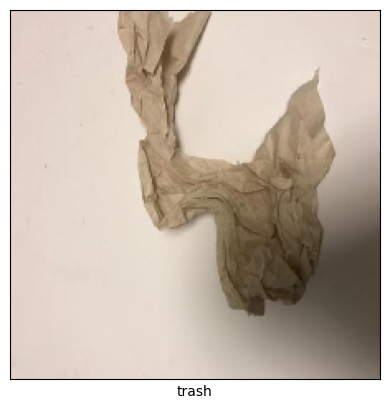

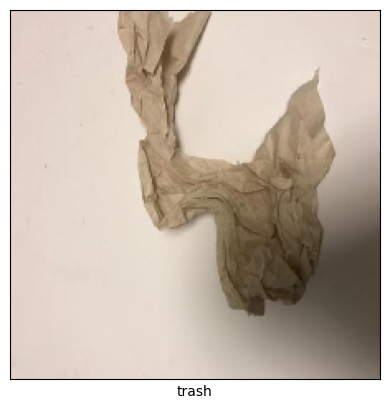

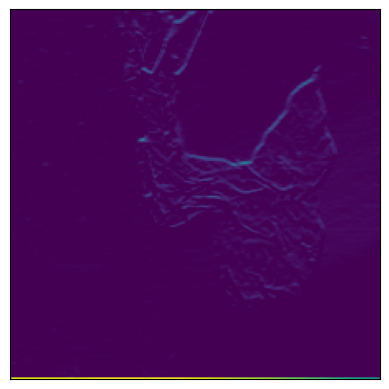

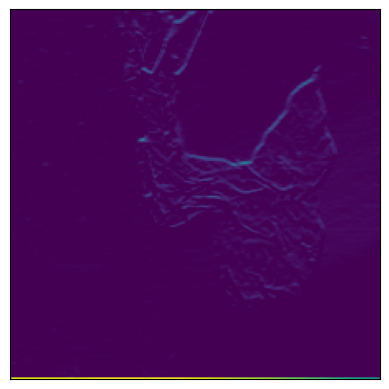

In [ ]:

filters = 2
X_batch, y_batch = next(iter(train_gen))
sample_image, sample_label = X_batch[:1], y_batch[:1]
plot_image(sample_image, sample_label)

sample_convolution = tf.keras.layers.Conv2D(
    filters=filters,
    kernel_size=(3,3),
    activation='relu', # !!!!!
    padding="same",
    use_bias=False
)

sample_transformed = sample_convolution(sample_image)

sample_kernel = tf.constant([
    [1,      1,     1],
    [0,      0,     0],
    [-1,    -1,    -1]
])

sample_kernel = tf.stack([sample_kernel, sample_kernel, sample_kernel], axis=-1)
sample_kernel_filters = tf.stack([sample_kernel, sample_kernel], axis=-1)

sample_convolution.set_weights([sample_kernel_filters])

sample_transformed = sample_convolution(sample_image)

plot_image(sample_image, sample_label)

for image in range(filters):
    # ... = :, :, :
    plot_image(sample_transformed[..., image])

In [ ]:
import keras

backbone = tf.keras.applications.mobilenet.MobileNet(weights='imagenet', include_top=False)
backbone.trainable = False

# a layer!
preprocessing = tf.keras.layers.Lambda(tf.keras.applications.mobilenet.preprocess_input)

model = tf.keras.Sequential([
    # Input shape should match generator's output (224, 224, 3)
    tf.keras.Input(shape=(224, 224, 3)),
    preprocessing,
    backbone,
    keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    
    tf.keras.layers.Dense(6, activation="softmax")
])

`input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.


In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,294,854 (12.57 MB)

 Trainable params: 65,990 (257.77 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:

loss = tf.keras.losses.CategoricalCrossentropy()

metrics = [tf.keras.metrics.CategoricalAccuracy()]
callbacks = [tf.keras.callbacks.EarlyStopping(patience=3)]

model.compile(
    loss=loss,
    optimizer='adamw',
    metrics=metrics
)

model.fit(
    train_gen, 
    epochs=10, 
    validation_data=valid_gen,
    callbacks=callbacks
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 368ms/step - categorical_accuracy: 0.2252 - loss: 1.7321 - val_categorical_accuracy: 0.2183 - val_loss: 1.7319
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 368ms/step - categorical_accuracy: 0.2252 - loss: 1.7321 - val_categorical_accuracy: 0.2183 - val_loss: 1.7319
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 347ms/step - categorical_accuracy: 0.2496 - loss: 1.7110 - val_categorical_accuracy: 0.3016 - val_loss: 1.7310
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 347ms/step - categorical_accuracy: 0.2496 - loss: 1.7110 - val_categorical_accuracy: 0.3016 - val_loss: 1.7310
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 356ms/step - categorical_accuracy: 0.2615 - loss: 1.7060 - val_categorical_accuracy: 0.2560 - val_loss: 1.7131
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 356ms/step - categorical_accuracy: 0.2615 - loss: 1.7060 - val_categorical_accuracy: 0.2560 - val_loss: 1.7131
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 352ms/step - categorical_accuracy: 0.249

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


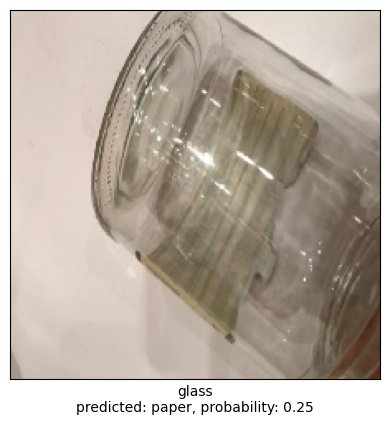

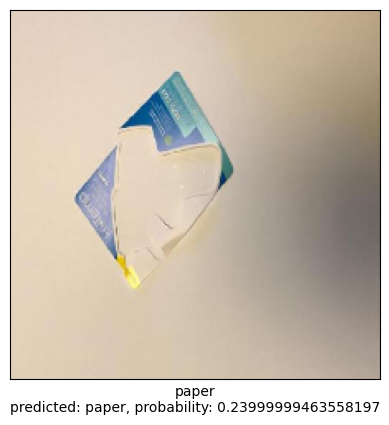

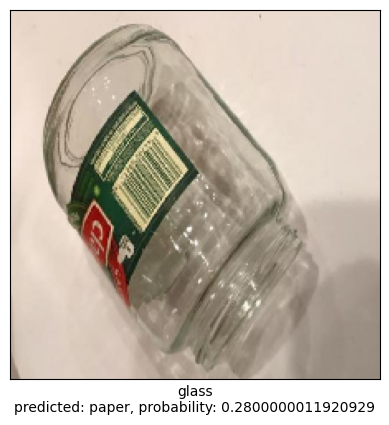

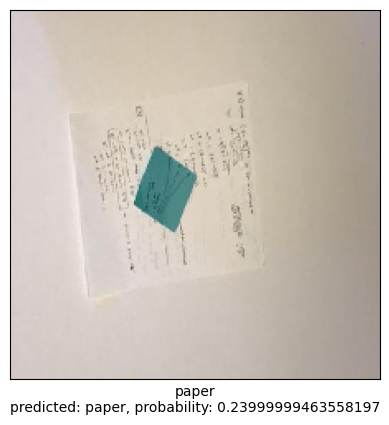

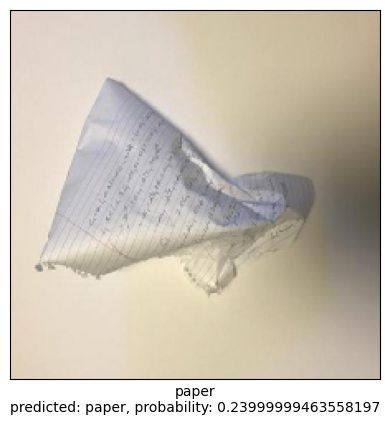

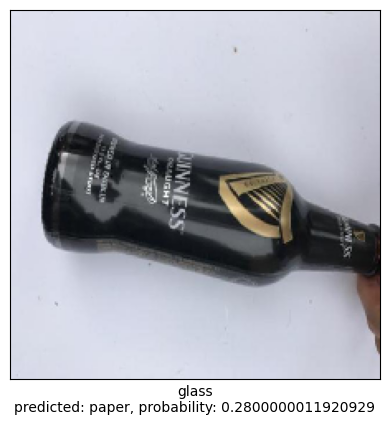

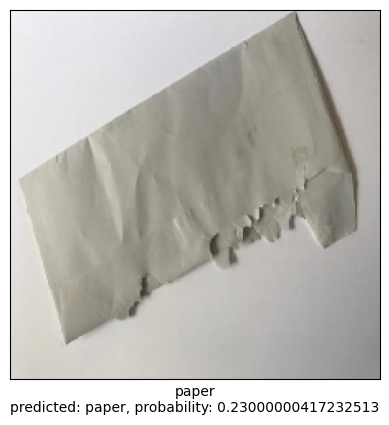

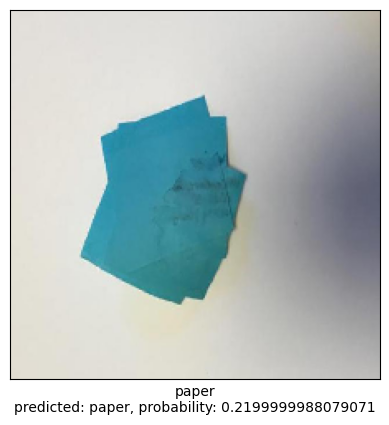

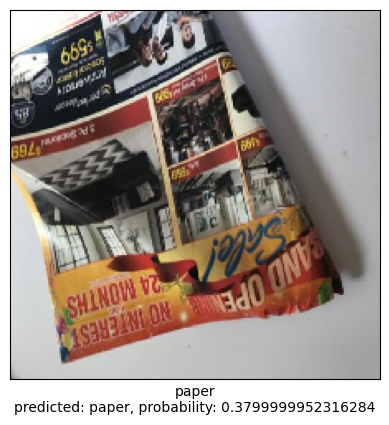

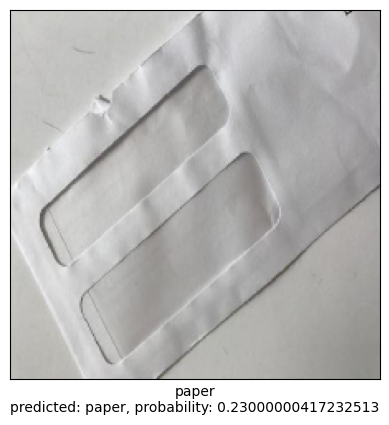

accuracy on this plotted sample:  0.7


In [25]:

X_test_batch, y_test_batch = next(iter(test_gen))
test_preds = model.predict(X_test_batch)
plot_image(X_test_batch, y_test_batch, test_preds)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

def extract_average_f1(report):
    f1_scores = []
    for cls in class_names:
        if cls in report:
            f1_scores.append(report[cls]['f1-score'])
            
    return np.mean(f1_scores) if f1_scores else 0

def predict_from_generator(generator):
    generator.reset()
    
    probabilities = model.predict(generator)
    predicted_classes = np.argmax(probabilities, axis=1)
    
    y_true_vectors = generator.labels
    
    y_true = np.argmax(y_true_vectors, axis=1)
    
    report_string = classification_report(y_true, predicted_classes, target_names=class_names, zero_division=0)
    print(report_string)
    
    return classification_report(y_true, predicted_classes, target_names=class_names, output_dict=True, zero_division=0)

print("\nFull Classification Report (test data):")
report_test = predict_from_generator(test_gen)

print("\nFull Classification Report (validation data):")
report_validate = predict_from_generator(valid_gen)

avg_f1 = np.mean([extract_average_f1(report_test), extract_average_f1(report_validate)])
print(f"Average f1 across test/valid: {avg_f1:.4f}")


Full Classification Report (test data):
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step
              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00        44
       glass       0.00      0.00      0.00        47
       metal       0.62      0.12      0.21        40
       paper       0.27      0.95      0.42        64
     plastic       0.28      0.11      0.16        44
       trash       0.00      0.00      0.00        14

    accuracy                           0.28       253
   macro avg       0.20      0.20      0.13       253
weighted avg       0.22      0.28      0.17       253


Full Classification Report (validation data):
              precision    recall  f1-score   support

   cardboard       0.00      0.00      0.00        44
       glass       0.00      0.00      0.00        47
       metal       0.62      0.12      0.21        40
       paper       0.27      0.95      0.42        64
     plastic       0